# 01b · Fraud SQL Investigation

Runs every named query in `sql/fraud_analysis.sql` and `sql/investigation_queries.sql` against the cleaned SQLite database and records what each one shows.

**Prerequisites** (run once from the project root):
```bash
python -m src.preprocessing   # raw CSV  -> data/processed/transactions_clean.parquet
python -m src.database        # parquet  -> data/processed/paysim.db
```

The cleaned data excludes the 16 zero-amount "fraud" CASH_OUTs identified in notebook 01 (kept in `data/processed/excluded_rows.csv`). Counts here are therefore 16 lower than in notebook 01.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.database import get_connection, load_named_queries, run_query

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.max_columns", 20)
LEGIT, FRAUD = "#2a78d6", "#eb6834"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold"})

conn = get_connection()
QUERIES = load_named_queries()


def show(name: str, **params) -> pd.DataFrame:
    """Print a query's business question and return its result."""
    query = QUERIES[name]
    print(f"Q: {query.question}")
    return run_query(conn, query, params or None)


print(f"{len(QUERIES)} named queries loaded:", ", ".join(QUERIES))

15 named queries loaded: dataset_overview, fraud_rate_by_type, amount_profile_by_class, fraud_rate_by_amount_band, fraud_by_day, fraud_by_hour_of_day, top_fraud_transactions, existing_rule_performance, full_balance_drain_rule, origin_balance_inconsistency, high_risk_pattern_matrix, transfer_to_cashout_chains, suspicious_destination_accounts, suspicious_origin_accounts, account_activity


# Part A: Fraud analysis (`sql/fraud_analysis.sql`)

### 1. Dataset overview

In [2]:
show("dataset_overview")

Q: How many transactions and how much money does the dataset contain, and what share of each is fraud?


,transactions,fraud_transactions,fraud_rate_pct,total_amount,fraud_amount,fraud_amount_pct
0,6362604,8197,0.1288,"1,144,392,944,759.7700","12,056,415,427.8400",1.0535


> **Finding:** 6,362,604 transactions, of which 8,197 are fraud (**0.1288%**). By value, fraud is **1.05%** of all money moved (12.06B of 1,144.39B). Fraud is a much larger share of value than of volume, because fraudulent transactions are larger on average.

### 2. Fraud rate and share by transaction type

In [3]:
show("fraud_rate_by_type")

Q: Which transaction types carry fraud, how risky is each one, and how much of all fraud does each account for?


,type,transactions,share_of_transactions_pct,fraud,fraud_rate_pct,share_of_fraud_pct
0,TRANSFER,532909,8.3800,4097,0.7688,49.9800
1,CASH_OUT,2237484,35.1700,4100,0.1832,50.0200
2,PAYMENT,2151495,33.8100,0,0.0000,0.0000
3,CASH_IN,1399284,21.9900,0,0.0000,0.0000
4,DEBIT,41432,0.6500,0,0.0000,0.0000


> **Finding:** This confirms notebook 01. Fraud occurs only in TRANSFER (0.7688% rate, 49.98% of fraud) and CASH_OUT (0.1832%, 50.02%). The only difference is that CASH_OUT now has 4,100 frauds instead of 4,116, after the 16 zero-amount rows were removed.

### 3. Amount profile by class

In [4]:
show("amount_profile_by_class")

Q: How do fraudulent and legitimate transaction amounts compare within the types where fraud occurs?


,type,class,transactions,avg_amount,min_amount,max_amount,total_amount
0,CASH_OUT,legitimate,2233384,"173,917.1600",0.0100,"2,847,566.6200","388,423,792,980.6600"
1,CASH_OUT,fraud,4100,"1,460,781.0400",63.8000,"10,000,000.0000","5,989,202,243.8300"
2,TRANSFER,legitimate,528812,"906,229.0100",2.6000,"92,445,516.6400","479,224,774,079.1600"
3,TRANSFER,fraud,4097,"1,480,891.6700",63.8000,"10,000,000.0000","6,067,213,184.0100"


> **Finding:**
> - In **CASH_OUT**, the average fraud (1.46M) is about 8× the average legitimate amount (174K). The largest legitimate CASH_OUT is 2,847,566.62, so **every CASH_OUT above that is fraud**. That is almost certainly a simulator artefact.
> - In **TRANSFER**, legitimate amounts are themselves large (average 906K, max 92.4M), so the gap is much smaller (1.48M fraud average).
> - *Implication:* amount separates fraud much better within CASH_OUT than within TRANSFER. A tree model can learn that interaction; logistic regression would need it engineered explicitly.

### 4. Fraud rate by amount band (TRANSFER and CASH_OUT)

Q: How does fraud risk change with transaction size, and does the 10,000,000 cap on fraud amounts show up?


,amount_band,transactions,fraud,fraud_rate_pct
0,1. under 10K,78825,262,0.3324
1,2. 10K to 100K,757271,1429,0.1887
2,3. 100K to 1M,1803790,3800,0.2107
3,4. 1M to under 10M,124857,2419,1.9374
4,5. exactly 10M,3207,287,8.9492
5,6. over 10M,2443,0,0.0000


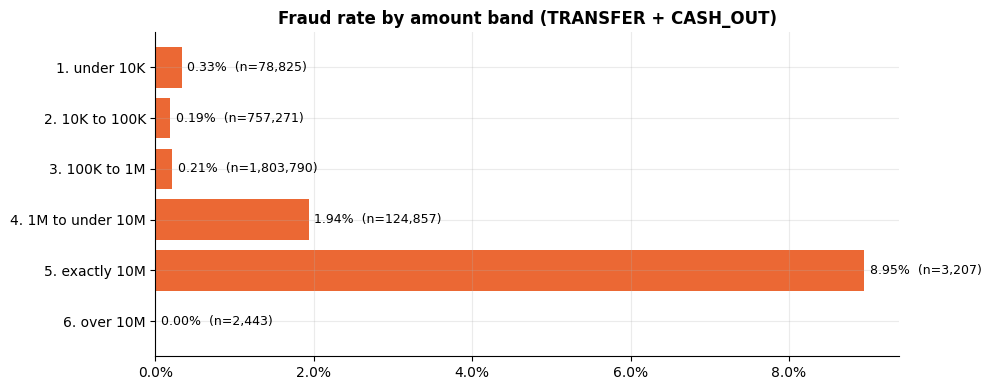

In [5]:
bands = show("fraud_rate_by_amount_band")
display(bands)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(bands["amount_band"], bands["fraud_rate_pct"], color=FRAUD)
ax.invert_yaxis()
ax.xaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
for y, (rate, n) in enumerate(zip(bands["fraud_rate_pct"], bands["transactions"])):
    ax.annotate(f"{rate:.2f}%  (n={n:,})", (rate, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_title("Fraud rate by amount band (TRANSFER + CASH_OUT)")
plt.tight_layout()
plt.show()

> **Finding:** Fraud risk rises with size, but not smoothly:
> - Below 1M the rate stays between 0.19% and 0.33% (the under-10K band is actually *higher* than 10K–100K).
> - It jumps to **1.94%** for 1M to under 10M, and **8.95%** at exactly 10M (287 of 3,207).
> - It is **0%** above 10M (2,443 transactions).
> - *Implication:* the 10M fraud cap creates a hard edge that a model can exploit. Real fraud has no such cap, so this is a stated limitation.

### 5. Fraud by simulated day

Q: Is fraud volume stable across the simulated month, and on which days does legitimate activity disappear?


,day,active_hours,transactions,fraud,fraud_rate_pct,fraud_only_hours
0,1,24,574255,271,0.0472,0
1,2,24,455238,309,0.0679,5
2,3,24,1070,310,28.9720,23
3,4,24,28240,262,0.9278,20
4,5,24,9789,252,2.5743,21
5,6,24,441005,228,0.0517,5
6,7,24,420583,272,0.0647,5
7,8,24,449637,278,0.0618,6
8,9,24,417918,254,0.0608,5
9,10,24,392945,282,0.0718,7


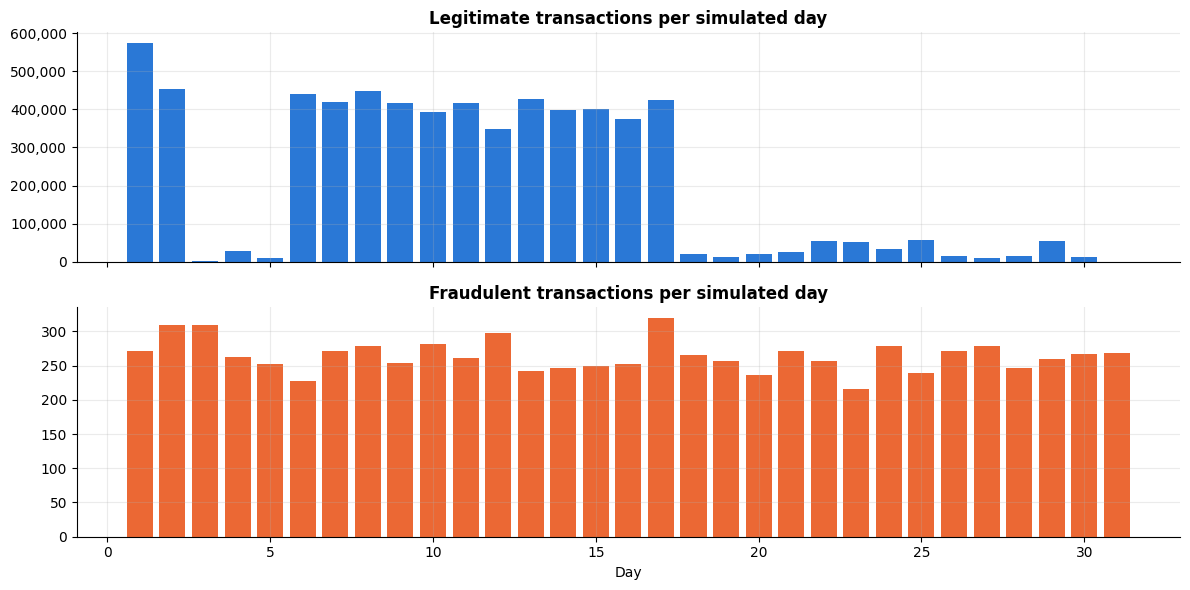

In [6]:
days = show("fraud_by_day")
display(days)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax1.bar(days["day"], days["transactions"] - days["fraud"], color=LEGIT)
ax1.set_title("Legitimate transactions per simulated day")
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax2.bar(days["day"], days["fraud"], color=FRAUD)
ax2.set_title("Fraudulent transactions per simulated day")
ax2.set_xlabel("Day")
plt.tight_layout()
plt.show()

> **Finding:** Fraud is **steady at 216–319 per day** for all 31 days. Legitimate traffic is not:
> - It collapses on days 3–5, recovers, then **collapses again from day 18 and never recovers**: at most 57,613 legitimate transactions per day afterwards (day 31 has none), against 349,478–573,984 on days 1–2 and 6–17.
> - Day 3 has only 1,070 transactions, 310 of them fraud (29%).
> - **Day 31 is 100% fraud** (269 transactions).
>
> This confirms the Phase 1 warning in SQL: time-based features, or a chronological train/test split, would mostly measure *when the simulator ran legitimate customers*, not fraud behaviour.

### 6. Fraud by hour of day

In [7]:
show("fraud_by_hour_of_day")

Q: Does fraud cluster at particular hours, or does the fraud rate move only because legitimate volume changes?


,hour_of_day,transactions,fraud,legitimate,fraud_rate_pct
0,0,71587,300,71287,0.4191
1,1,27111,358,26753,1.3205
2,2,9017,371,8646,4.1145
3,3,2006,325,1681,16.2014
4,4,1241,274,967,22.0790
5,5,1641,366,1275,22.3035
6,6,3419,357,3062,10.4416
7,7,8988,328,8660,3.6493
8,8,26915,368,26547,1.3673
9,9,283518,341,283177,0.1203


> **Finding:** Fraud counts are flat (274–371 per hour). The rate peaks at hours 3–5 (16–22%) only because legitimate volume falls to 967–1,681 transactions in those hours. The rate rises because the denominator shrinks, not because there is more fraud.

# Part B: Investigation queries (`sql/investigation_queries.sql`)

### 7. Highest-value fraudulent transactions

In [8]:
show("top_fraud_transactions")

Q: What are the highest-value fraudulent transactions, and what do their balances show?


,transaction_id,step,type,amount,name_orig,old_balance_orig,new_balance_orig,name_dest,old_balance_dest,new_balance_dest,is_flagged_fraud
0,4441,4,TRANSFER,"10,000,000.0000",C7162498,"12,930,418.4400","2,930,418.4400",C945327594,0.0000,0.0000,0
1,4442,4,CASH_OUT,"10,000,000.0000",C351297720,"10,000,000.0000",0.0000,C766681183,0.0000,"9,941,904.2100",0
2,481251,19,TRANSFER,"10,000,000.0000",C416779475,"11,861,008.3200","1,861,008.3200",C380259496,0.0000,0.0000,0
3,481252,19,CASH_OUT,"10,000,000.0000",C2050703310,"10,000,000.0000",0.0000,C1622860679,"504,326.6200","10,342,417.9000",0
4,586312,33,TRANSFER,"10,000,000.0000",C1439740840,"19,887,819.0600","9,887,819.0600",C875288652,0.0000,0.0000,0
5,586313,33,CASH_OUT,"10,000,000.0000",C29118015,"10,000,000.0000",0.0000,C1379703840,0.0000,"10,000,000.0000",0
6,1030560,72,TRANSFER,"10,000,000.0000",C53057884,"18,594,065.0900","8,594,065.0900",C588547519,0.0000,0.0000,0
7,1030561,72,CASH_OUT,"10,000,000.0000",C1438388258,"10,000,000.0000",0.0000,C1089455271,"81,810.4200","10,081,810.4200",0
8,1030662,82,TRANSFER,"10,000,000.0000",C1237313447,"10,987,591.5900","987,591.5900",C1468356154,0.0000,0.0000,0
9,1030663,82,CASH_OUT,"10,000,000.0000",C1079335762,"10,000,000.0000",0.0000,C615227407,"373,274.8400","10,373,274.8400",0


> **Finding:**
> - All top 20 are exactly 10,000,000, and they come in **TRANSFER / CASH_OUT pairs at the same step with consecutive `transaction_id`s**.
> - In each pair, the TRANSFER's origin account is *not* fully drained (e.g. 12.93M → 2.93M), because the 10M cap stops it.
> - The existing rule flag (`is_flagged_fraud`) is 0 on all 20, even though these are the largest frauds in the data.

### 8. Existing rule performance (`is_flagged_fraud`)

In [9]:
show("existing_rule_performance")

Q: How well does PaySim's existing rule flag (is_flagged_fraud) catch fraud? This is the bar any model must beat.


,true_positives,false_positives,false_negatives,true_negatives,precision_pct,recall_pct
0,16,0,8181,6354407,100.0000,0.2000


> **Finding:** The existing rule catches **16 of 8,197 frauds**: precision 100%, **recall 0.20%**. It never raises a false alarm, but it misses 8,181 frauds (false negatives). This is the operational baseline any model has to beat.

### 9. A one-line rule: "the transaction moves the entire origin balance"

In [10]:
show("full_balance_drain_rule")

Q: If an analyst flagged every TRANSFER/CASH_OUT that moves the entire origin balance, what precision and recall would that simple rule get?


,pattern,transactions,fraud,fraud_rate_pct,share_of_fraud_pct
0,moves entire balance,8018,8018,100.0000,97.8200
1,other,2762375,179,0.0065,2.1800


> **Finding (the most important result of this phase):** this single SQL condition flags 8,018 transactions, **all of which are fraud**: **100% precision and 97.82% recall**. Only 179 frauds fall outside it.
>
> *What this means for the project:*
> - The PaySim fraud agent was evidently coded to empty the victim's account, so this is an artefact of the simulator. Real fraudsters often do not drain accounts in one transaction.
> - Any ML model trained on these balance columns will score near-perfectly, and that tells us little about real-world performance.
> - **Phase 3/4 plan:** (1) report this rule as an explicit baseline next to every model; (2) train and compare models *with* and *without* the origin-balance features, to show what the model learns beyond the artefact.

### 10. Origin balance consistency

In [11]:
show("origin_balance_inconsistency")

Q: How often does the origin balance fail to change by exactly the amount, and how risky is each kind of inconsistency?


,origin_balance_state,transactions,fraud,fraud_rate_pct
0,1. consistent (old - amount = new),270342,8152,3.0154
1,"2. amount exceeds balance, balance floored at 0",2488631,29,0.0012
2,3. other inconsistency,11420,16,0.1401


> **Finding (counter-intuitive):** In this dataset **fraud is the *consistent* behaviour.**
> - Transactions where old − amount = new have a **3.02%** fraud rate (8,152 of 270,342).
> - Transactions where the amount exceeded the balance and the balance was floored at 0 have **0.0012%** (29 of 2.49M).
> - The usual intuition that "balance inconsistencies indicate fraud" is *reversed* here: simulated legitimate customers overspend, while the simulated fraudster moves exactly what is there.
> - *Implication:* an engineered "balance error" feature will be informative, but the direction of the effect must come from the data, not from intuition. This is a good interview example.

### 11. High-risk pattern matrix

In [12]:
show("high_risk_pattern_matrix")

Q: How do the two strongest balance signals combine? Fraud rate for every combination of 'drains origin account' and 'destination stays at 0'.


,drains_origin,dest_stays_zero,transactions,fraud,fraud_rate_pct
0,1,0,4096,4096,100.0000
1,1,1,3922,3922,100.0000
2,0,1,1854,148,7.9827
3,0,0,2760521,31,0.0011


> **Finding:**
> - Draining the origin account is **100% fraud whether or not** the destination balance stays at 0 (4,096 + 3,922 transactions).
> - Without a drain, a destination that stays at 0 still carries a **7.98%** fraud rate (148 of 1,854), about 7,000× the 0.0011% rate when neither pattern is present.
> - The destination signal therefore adds information that the drain signal misses.

### 12. TRANSFER → CASH_OUT chains

In [13]:
show("transfer_to_cashout_chains")

Q: How often is a TRANSFER followed by a CASH_OUT of the same amount in the same hour, and is that chain specific to fraud?


,transfer_is_fraud,cashout_is_fraud,matched_pairs,distinct_transfers
0,1,1,4272,4078
1,1,0,6,6
2,0,1,804,804
3,0,0,60,60


Are the two legs of a chain connected through accounts (the transfer's recipient is the cash-out's sender), or only by timing?

In [14]:
run_query(conn, '''
    SELECT COUNT(*)                                      AS fraud_pairs,
           SUM(t.name_dest = c.name_orig)                AS transfer_dest_is_cashout_origin,
           SUM(c.transaction_id = t.transaction_id + 1)  AS cashout_is_next_row
    FROM transactions t
    JOIN transactions c
      ON c.type = 'CASH_OUT' AND c.step = t.step AND c.amount = t.amount AND c.is_fraud = 1
    WHERE t.type = 'TRANSFER' AND t.is_fraud = 1
''')

,fraud_pairs,transfer_dest_is_cashout_origin,cashout_is_next_row
0,4272,0,4075


> **Finding:**
> - **4,078 of 4,097 fraud TRANSFERs (99.5%)** have a fraud CASH_OUT of the same amount in the same step.
> - Legitimate transfers match a fraud cash-out 804 times, and *all 804 are at exactly 10M* (verified in pandas). That is a coincidence caused by the fraud amount cap, not a real chain. Only 60 legitimate–legitimate pairs exist.
> - **The legs are not linked by account:** in 0 of 4,272 pairs does the transfer's recipient match the cash-out's sender. The cash-out is the *next row* in 4,075 pairs.
> - *Implication:* the chain is visible only through file order and timing. A real-time model scoring the TRANSFER would not yet have seen the CASH_OUT, so chain features would leak. **This will not be used as a model feature.** It stays an investigation tool.

### 13. Suspicious destination accounts (candidate mule accounts)

In [15]:
show("suspicious_destination_accounts")

Q: Which destination accounts received the most fraudulent transfers? These are candidate mule accounts.


,name_dest,fraud_received,legitimate_received,fraud_amount_received,first_fraud_step,last_fraud_step
0,C668046170,2,3,"10,160,088.6800",269,686
1,C1669818195,2,2,"8,848,239.9900",446,571
2,C1981613973,2,23,"7,265,501.6700",72,88
3,C1366192319,2,10,"7,061,799.6500",84,344
4,C964377943,2,2,"6,014,862.3900",300,401
5,C14138104,2,0,"4,597,314.2800",415,436
6,C1399829166,2,23,"3,540,009.2800",212,314
7,C643624257,2,15,"3,071,716.9700",250,279
8,C1013511446,2,33,"2,994,972.2000",9,74
9,C1601170327,2,14,"2,842,694.9900",148,281


> **Finding:**
> - **No destination account received more than 2 fraudulent transactions.** The top accounts each received 2 frauds, alongside 0–75 legitimate payments.
> - Fraud is not concentrated in a small set of mule accounts, unlike many real fraud rings.
> - (Notebook 01's "67% of fraud destinations are reused" reflects reuse by *legitimate* traffic, not repeated fraud.)
> - *Implication:* destination-history features are unlikely to add much, and would have to be built from prior activity only.

### 14. Suspicious origin accounts (repeat victims)

In [16]:
show("suspicious_origin_accounts")

Q: Do any origin accounts make more than one transaction including fraud? Repeat victims would show up here.


,name_orig,transactions,fraud,types_used,total_amount,first_step,last_step
0,C686187434,2,1,"CASH_OUT,CASH_IN","6,363,943.3600",13,329
1,C812001868,2,1,"CASH_IN,CASH_OUT","4,704,536.8500",286,379
2,C1191696703,2,1,TRANSFER,"3,215,956.1200",133,408
3,C483009518,2,1,"PAYMENT,TRANSFER","3,106,348.3700",236,297
4,C1015856166,2,1,"PAYMENT,CASH_OUT","2,603,467.0500",257,453
5,C635739031,2,1,"TRANSFER,CASH_OUT","2,199,793.6300",449,451
6,C2004363483,2,1,"TRANSFER,CASH_OUT","1,300,743.1200",253,461
7,C876181265,2,1,"PAYMENT,CASH_OUT","1,294,503.5000",209,243
8,C1851065642,2,1,"CASH_IN,CASH_OUT","1,155,380.2700",277,601
9,C1127304441,2,1,CASH_OUT,"1,049,698.5100",155,475


> **Finding:** Every origin account involved in fraud that appears more than once has exactly **one** fraudulent transaction, and at most 2 transactions in total. **There are no repeat victims**, which is consistent with the near-unique origin IDs found in notebook 01.

### 15. Account activity (parameterised)
This is the drill-down an analyst (and later the dashboard) uses on a single account. Demonstrated on the most active destination account in the data.

In [17]:
activity = show("account_activity", account="C1286084959")
print(f"{len(activity)} transactions")
activity.head(20)

Q: What is the full transaction history of one account, as sender or receiver? (Parameter: :account)
113 transactions


,transaction_id,step,type,amount,direction,name_orig,old_balance_orig,new_balance_orig,name_dest,old_balance_dest,new_balance_dest,is_fraud
0,94,1,TRANSFER,"583,848.4600",received,C1839168128,0.0000,0.0000,C1286084959,"667,778.0000","2,107,778.1100",0
1,368,1,TRANSFER,"176,334.2600",received,C169880779,"45,136.0000",0.0000,C1286084959,"1,251,626.4600","2,107,778.1100",0
2,389,1,CASH_OUT,"373,068.2600",received,C1047934137,"20,034.0000",0.0000,C1286084959,"1,427,960.7300","2,107,778.1100",0
3,472,1,CASH_IN,"403,418.3900",received,C848097505,"3,834,666.9500","4,238,085.3400",C1286084959,"1,801,028.9900","2,107,778.1100",0
4,643,1,CASH_IN,"222,126.9500",received,C870322840,"6,688,712.6400","6,910,839.5900",C1286084959,"1,397,610.6000","2,107,778.1100",0
5,660,1,CASH_IN,"317,393.3800",received,C1197721383,"8,906,617.3800","9,224,010.7500",C1286084959,"1,175,483.6500","2,107,778.1100",0
6,702,1,CASH_OUT,"18,288.9100",received,C1049590050,0.0000,0.0000,C1286084959,"858,090.2800","2,107,778.1100",0
7,804,1,TRANSFER,"483,544.3000",received,C593447952,0.0000,0.0000,C1286084959,"876,379.1900","2,107,778.1100",0
8,842,1,CASH_OUT,"607,616.7300",received,C1267042315,0.0000,0.0000,C1286084959,"1,359,923.4900","2,107,778.1100",0
9,1158,1,TRANSFER,"789,419.0200",received,C883678948,0.0000,0.0000,C1286084959,"1,967,540.2200","2,107,778.1100",0


> **Finding (data quality):**
> - Within step 1, `new_balance_dest` shows the **same value (2,107,778.11) on many consecutive transactions** while `old_balance_dest` changes from row to row.
> - So destination balances are **not running balances** that update after each transaction.
> - This is another reason destination-balance features must be treated cautiously and described as a limitation.

## Summary

| # | Query | Key result |
|---|---|---|
| 1 | dataset_overview | 8,197 frauds (0.1288% of transactions, 1.05% of value) |
| 2 | fraud_rate_by_type | Fraud only in TRANSFER (0.77%) and CASH_OUT (0.18%) |
| 3 | amount_profile_by_class | Every CASH_OUT above 2.85M is fraud |
| 4 | fraud_rate_by_amount_band | 8.95% fraud at exactly 10M; 0% above it |
| 5 | fraud_by_day | Fraud steady (216–319/day); legitimate volume collapses on days 3–5 and from day 18 onwards; day 31 is 100% fraud |
| 6 | fraud_by_hour_of_day | Rate peaks at night only because legitimate volume drops |
| 7 | top_fraud_transactions | Largest frauds are 10M TRANSFER/CASH_OUT pairs, none flagged |
| 8 | existing_rule_performance | Existing rule: 100% precision, **0.20% recall** |
| 9 | full_balance_drain_rule | One SQL rule: **100% precision, 97.82% recall** (simulator artefact) |
| 10 | origin_balance_inconsistency | Fraud is the *consistent* ledger behaviour (3.02% vs 0.0012%) |
| 11 | high_risk_pattern_matrix | "Destination stays 0" adds signal beyond "drains origin" (7.98%) |
| 12 | transfer_to_cashout_chains | 99.5% of fraud transfers chain to a cash-out, linked only by time/order, so it is investigation-only |
| 13 | suspicious_destination_accounts | No account received more than 2 frauds, so there are no mule hubs |
| 14 | suspicious_origin_accounts | No repeat victims |
| 15 | account_activity | Destination balances are not running balances |

### Decisions carried into Phase 3 (feature engineering)
1. Benchmark every model against **both** rules: the existing flag (0.20% recall) and the balance-drain rule (97.82% recall).
2. Train with and without origin-balance features, to separate real learning from the simulator artefact.
3. Exclude from features: `step`/time, account IDs, `is_flagged_fraud`, chain/next-row features, and any whole-dataset account counts.

In [18]:
conn.close()